# Multiple Linear Regression and Support Vector Regression (SVR)

## Health Insurance Cost Prediction

### Machine Learning Regression Project

**Author:** Juan Manuel Candela | **Date:** March 2026
**Dataset:** Medical Cost Personal Datasets

**Source:** Kaggle – Medical Cost Personal Dataset  
https://www.kaggle.com/datasets/mirichoi0218/insurance

---

## 1. Project Overview

This project analyzes a health insurance dataset to predict the **medical insurance cost** based on personal and demographic attributes. The objective is to build regression models that estimate the expected insurance charges using **Multiple Linear Regression (MLR)** and **Support Vector Regression (SVR)**.

The dataset was provided by a health insurance company and includes information related to demographic characteristics, lifestyle factors, and geographic region.

## Dataset Features

* **Age** – Age of the insured person
* **Sex** – Gender of the individual
* **BMI** – Body Mass Index
* **Children** – Number of dependents covered by the insurance
* **Smoker** – Whether the person is a smoker or not
* **Region** – Residential area of the insured person

## Includes

* Reading and exploring CSV data
* Data cleaning and inspection
* Handling missing values
* One-hot encoding for categorical variables
* Train–test split for model validation
* Feature scaling using StandardScaler
* Multiple Linear Regression model
* Support Vector Regression (SVR)
* Hyperparameter tuning with GridSearchCV
* Model evaluation using **Mean Squared Error (MSE)** and **R² score**
* Scatter plots comparing real vs predicted values


## Libraries

In [3]:
# Data manipulation
import numpy as np
import pandas as pd
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

## 2. Exploratory Data Analysis (EDA) & Data Preprocessing & Cleaning


In [ ]:
# Read csv
df = pd.read_csv("insurance.csv")

df.head()
df.info()
df.describe()

print()
# Show amount of data
print(f"The dataset has {len(df)} records")

# Chagers mean
print(f"The mean of charges is: ${df['charges'].mean():.2f}")

# Max number of children

print(f"The person with the most children has: {df['children'].max()} children")

# Standar deviation

print(f"The standard deviation of BMI is: {df['bmi'].std():.3f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
The dataset has 1338 records
The mean of charges is: $13270.42
The person with the most children has: 5 children
The standard deviation of BMI is: 6.098


### Correlation matrix

In [11]:
# Keep numeric values
df_corr = df.drop(["region", "sex", "smoker"], axis=1)
def matrix_corr(df):
    mascara = np.triu(df.corr(numeric_only=True)).T

    fig, ax = plt.subplots()

    sns.heatmap(df.corr(numeric_only=True),
                annot=True,
                lw=0.5,
                mask=mascara)

    ax.set_title("Correlation matrix")
    plt.tight_layout()
    plt.show()  

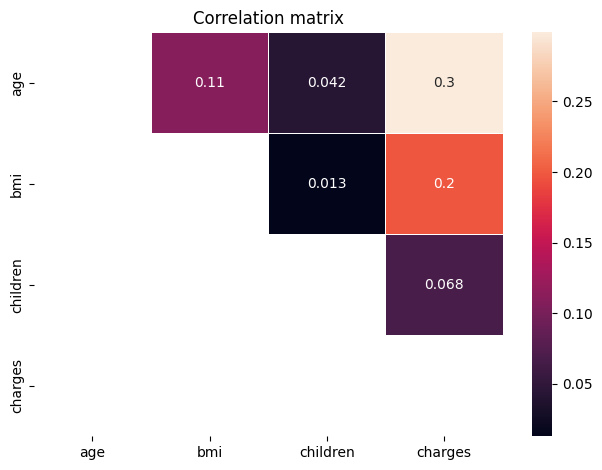

In [12]:
matrix_corr(df_corr)

- In the correlation matrix, we can observe that older people tend to pay higher health charges. Additionally, individuals with higher BMI values tend to get sick more frequently, which may lead to higher healthcare costs.

### Pairplot: Smokers vs Non-Smokers

In [76]:
def pairplot_smokers_vs_no_smokers(df):
    
    g = sns.pairplot(df,
                     hue="smoker",
                     vars=["age", "bmi", "charges"],
                     palette="inferno")
    
    g.fig.suptitle("Smokers vs No smokers", y=1)

    plt.show()

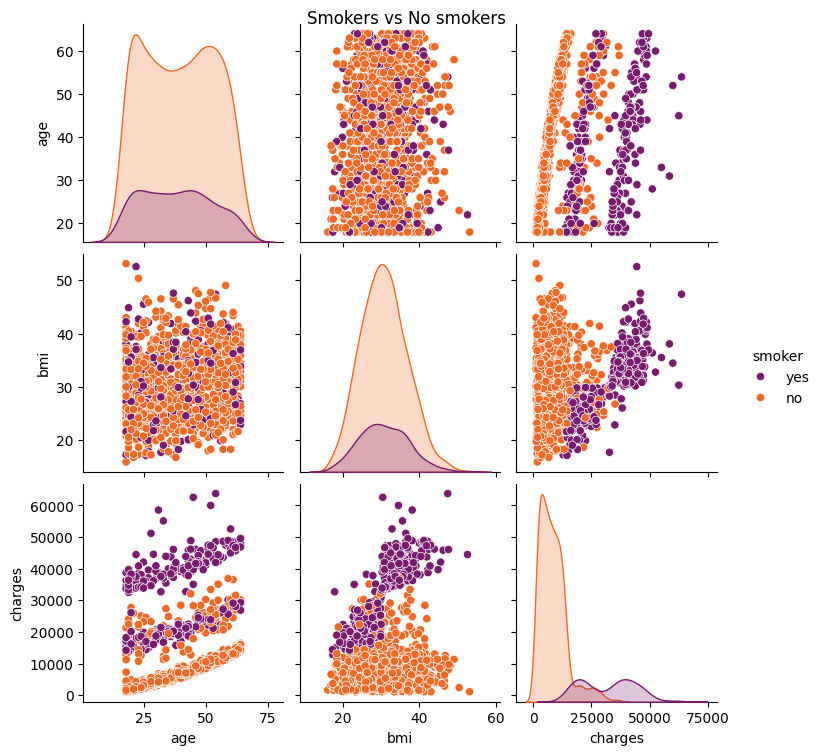

In [77]:
pairplot_smokers_vs_no_smokers(df) 

- In the pairplot, we can observe that smokers tend to have higher health charges than non-smokers. They also appear to have higher BMI values in the dataset, which may be associated with increased health risks.

### Data Distribution by Region

In [54]:
def region_distribution(df):
    sns.histplot(df, x="region", stat="percent")
    plt.show()

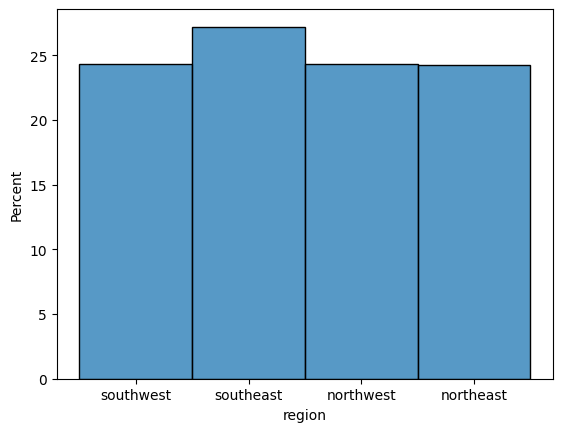

In [55]:
region_distribution(df)

- The dataset contains slightly more observations from the Southeast region.

### Preprocessing

In [17]:
print(df.isnull().sum()) # Check for null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
# One hot Encoding
def one_hot_encoding(df):
    ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(), make_column_selector(dtype_include=object))], remainder='passthrough')
    df_trans = ct.fit_transform(df)
    columns = ct.get_feature_names_out() # Recover column names
    df_trans = pd.DataFrame(df_trans, columns=columns)
    return df_trans, ct

In [62]:
X = df.drop(["charges"], axis=1)
# Target
y = df["charges"]

# OnehotEncoding in DF
X, ct = one_hot_encoding(X)

# Data split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
sc = StandardScaler()
X_train[["remainder__age" , "remainder__bmi" , "remainder__children"]] = sc.fit_transform(X_train[["remainder__age" , "remainder__bmi" , "remainder__children"]])
X_test[["remainder__age" , "remainder__bmi" , "remainder__children"]] = sc.transform(X_test[["remainder__age" , "remainder__bmi" , "remainder__children"]])

##  3. Model Development

#### Linear Regression Model

In [21]:
# Linear regression model
def linear_regression(X_train, X_test, y_train, y_test):
    lr = LinearRegression()

    lr.fit(X_train, y_train)

    # Prediction
    y_pred_mlr = lr.predict(X_test)

    # Metrics

    # mean squared error
    mse = mean_squared_error(y_test, y_pred_mlr)

    #R2 score
    r2 = r2_score(y_test, y_pred_mlr)
    
    return mse, r2, y_pred_mlr, lr

# Unpack MLR
mse_mlr, r2_mlr, y_pred_mlr, lr = linear_regression(X_train, X_test, y_train, y_test)

#### Support Vector Regression (SVR)

In [64]:
# Support Vector Regression (SVR)
def support_vector_regression(X_train, X_test, y_train, y_test):
    parameters = {"kernel": ["rbf"],
                "C": [1, 10, 50, 100, 500, 1000],
                "epsilon": [0.01, 0.1, 0.5],
                "gamma": ["scale", 0.01, 0.05, 0.1]}



    # Model
    # Instantiate
    svr = SVR()
    # GridSearchCV to find the best hyperparameters
    regr = GridSearchCV(svr,
                        parameters,
                        scoring="neg_mean_squared_error",
                        n_jobs=-1)

    # Fit
    regr.fit(X_train, y_train)

    print(regr.best_params_)
    # Predict
    y_pred = regr.predict(X_test)

    # Metrics
    # Mean squared error
    mse = mean_squared_error(y_test, y_pred)

    #R2 score
    r2 = r2_score(y_test, y_pred)


    return mse, r2, y_pred, regr

# Unpack SVR
mse_svr, r2_svr, y_pred_svr, regr = support_vector_regression(X_train, X_test, y_train, y_test)

{'C': 1000, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}


### Linear Regression Vs Support Vector

In [68]:
def graph_svr_vs_mlr(y_test, y_pred_svr, y_pred_mlr):
    # graph
    fig, ax = plt.subplots(1,2, figsize=(18,6))

    # MLR
    ax[0].scatter(y_test, y_pred_mlr, marker=".", alpha=0.6)
    ax[0].set_title("Linear Regression model")
    ax[0].set_xlabel("Real charges")
    ax[0].set_ylabel("predicted charges")

    # SVR
    ax[1].scatter(y_test, y_pred_svr, marker=".", alpha=0.6)
    ax[1].set_title("Support Vector Regression")
    ax[1].set_xlabel("Real charges")
    ax[1].set_ylabel("predicted charges")

    # Same limits for both plots
    lims = [
        min(y_test.min(), y_pred_svr.min(), y_pred_mlr.min()),
        max(y_test.max(), y_pred_svr.max(), y_pred_mlr.max())
    ]

    for i in range(2):
        ax[i].plot(lims, lims, '--', color='black')
        ax[i].set_xlim(lims)
        ax[i].set_ylim(lims)

    plt.tight_layout()
    plt.show()

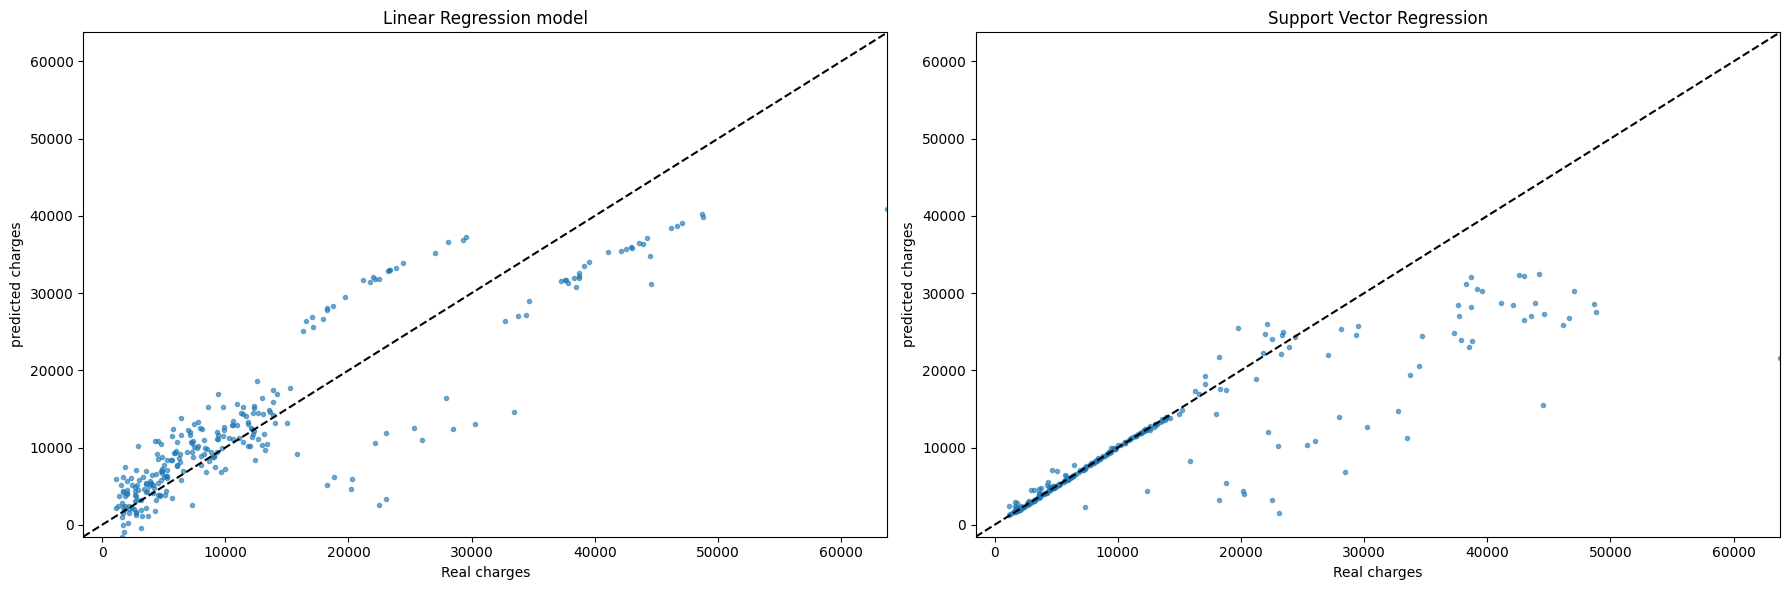

In [69]:
graph_svr_vs_mlr(y_test, y_pred_svr, y_pred_mlr)

#### Metrics

Linear Regression model

In [36]:
print(f"RMSE linear regression model: ${np.sqrt(mse_mlr):.3f}\nR² linear regression model: {r2_mlr:.3f}")

RMSE linear regression model: $5796.285
R² linear regression model: 0.784


Support Vector Regression model

In [70]:
print(f"RMSE support vector regression model: ${np.sqrt(mse_svr):.3f}\nR² support vector regression model: {r2_svr:.3f}")

RMSE support vector regression model: $6922.162
R² support vector regression model: 0.691


Features with the highest influence on the prediction

In [79]:
pd.Series(lr.coef_, index=X_train.columns).sort_values()

encoder__smoker_no          -11825.564428
encoder__region_southwest     -350.214110
encoder__region_southeast     -198.279052
encoder__sex_male               -9.295846
encoder__sex_female              9.295846
encoder__region_northwest       88.907918
encoder__region_northeast      459.585244
remainder__children            516.890247
remainder__bmi                2036.228123
remainder__age                3614.975415
encoder__smoker_yes          11825.564428
dtype: float64

- After running both models, the Linear Regression model fits this dataset better. It achieves a Root Mean Squared Error (RMSE) of 5796 and a Coefficient of Determination (R²) of 78%. On the other hand, SVR shows a worse fit, with an RMSE of 6922 and an R² of 69%, as well as greater variability in its predictions.
- In the SVR model, the predictions fit better for observations with lower charges, while the Linear Regression model performs better when predicting higher charge values.

## Model test

- We are going to try a prediction with the first client of the dataset

In [41]:
# Client prediction
person_test = pd.DataFrame({"age":	[19],
                            "sex": ["female"],
                            "bmi": [27.9],
                            "children": [0],
                            "smoker": ["yes"],
                            "region": ["southwest"]}) #Charge of $16884.924

# Person transform
person_trans = ct.transform(person_test)
person_trans = pd.DataFrame(person_trans, columns=ct.get_feature_names_out())
person_trans[["remainder__age" , "remainder__bmi" , "remainder__children"]] = sc.transform(person_trans[["remainder__age" , "remainder__bmi" , "remainder__children"]])

person_pred_mlr = lr.predict(person_trans)

person_pred_svr = regr.predict(person_trans)

print(f"Linear regression charge predict: {person_pred_mlr[0]:.4f}")
print(f"Support vector regression charge predict: {person_pred_svr[0]:.4f}")

Linear regression charge predict: 25197.5311
Support vector regression charge predict: 17253.5869


- High charge prediction

In [ ]:
# Find high charges in the dataset

df.query("charges > 48000").sort_values("charges", ascending=False)

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
34,28,male,36.400,1,yes,southwest,51194.55914
1241,64,male,36.960,2,yes,southeast,49577.66240
1062,59,male,41.140,1,yes,southeast,48970.24760
488,44,female,38.060,0,yes,southeast,48885.13561


In [ ]:
# Client prediction with high charge
person_test = pd.DataFrame({"age":	[59],
                            "sex": ["male"],
                            "bmi": [41.140],
                            "children": [1],
                            "smoker": ["yes"],
                            "region": ["southeast"]}) #Charge of $ 48970.24760

# Person transform
person_trans = ct.transform(person_test)
person_trans = pd.DataFrame(person_trans, columns=ct.get_feature_names_out())
person_trans[["remainder__age" , "remainder__bmi" , "remainder__children"]] = sc.transform(person_trans[["remainder__age" , "remainder__bmi" , "remainder__children"]])

person_pred_mlr = lr.predict(person_trans)

person_pred_svr = regr.predict(person_trans)

print(f"Linear regression charge predict: {person_pred_mlr[0]:.4f}")
print(f"Support vector regression charge predict: {person_pred_svr[0]:.4f}")

Linear regression charge predict: 40498.2868
Support vector regression charge predict: 30955.4607


- In this case, the Linear Regression model produced a better prediction, likely because it handles higher charge values more effectively in this dataset.

# Final toughts

#### - After analyzing this dataset using Multiple Linear Regression (MLR) and Support Vector Regression (SVR), we can observe that the linear model provides a better overall fit, particularly when predicting higher charge values, while SVR performs relatively better for lower values. The analysis also suggests that smokers tend to have higher healthcare charges, and individual with higher BMI values also tend to pay slighly more, indicating that BMI is a relevant feature influencing healthcare costs in this dataset.